In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/kidneyData.csv
/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Cyst/Cyst- (3178).jpg
/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Cyst/Cyst- (3561).jpg
/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Cyst/Cyst- (900).jpg
/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Cyst/Cyst- (1148).jpg
/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Cyst/Cyst- (268).jpg
/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-S

In [2]:
# Import

import torch
import torch.nn as nn
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, random_split, WeightedRandomSampler
import timm
from torch.cuda.amp import autocast, GradScaler
import matplotlib.pyplot as plt
from tqdm import tqdm
from collections import Counter
from sklearn.metrics import precision_score, recall_score, f1_score
from torch.utils.tensorboard import SummaryWriter
import os

2025-11-19 09:12:50.212313: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763543570.436605      38 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763543570.500591      38 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
import os
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report

# Config - change BASE_DIR to your dataset path if different
BASE_DIR = "/kaggle/working/Balanced_CT_Kidney"   # folder with subfolders for classes
IMG_SIZE = (224, 224)   # VGG16 standard input
BATCH_SIZE = 16
SEED = 42
MODEL_PATH = "/kaggle/working/vgg16_best.keras"


In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

BASE_DIR = "/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone"

# verify
print("Exists:", os.path.exists(BASE_DIR))
print("Subfolders:", sorted(os.listdir(BASE_DIR))[:10])

IMG_SIZE = (128, 128)   # change to (224,224) for ResNet/VGG etc.
BATCH_SIZE = 24

datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

train_gen = datagen.flow_from_directory(
    BASE_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

val_gen = datagen.flow_from_directory(
    BASE_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

print("Classes:", train_gen.class_indices)
print("Train samples:", train_gen.samples, "Val samples:", val_gen.samples)


Exists: True
Subfolders: ['Cyst', 'Normal', 'Stone', 'Tumor']
Found 9959 images belonging to 4 classes.
Found 2487 images belonging to 4 classes.
Classes: {'Cyst': 0, 'Normal': 1, 'Stone': 2, 'Tumor': 3}
Train samples: 9959 Val samples: 2487


In [5]:
# Augmentation for train, only rescale for val
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    BASE_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=SEED
)

val_gen = train_datagen.flow_from_directory(
    BASE_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=SEED
)

class_indices = train_gen.class_indices
NUM_CLASSES = len(class_indices)
print("Classes:", class_indices)
print("Train samples:", train_gen.samples, "Val samples:", val_gen.samples)


Found 9959 images belonging to 4 classes.
Found 2487 images belonging to 4 classes.
Classes: {'Cyst': 0, 'Normal': 1, 'Stone': 2, 'Tumor': 3}
Train samples: 9959 Val samples: 2487


In [6]:
import os

for p in ["/kaggle/input", "/kaggle/working"]:
    print("\nChecking:", p)
    print(os.listdir(p))



Checking: /kaggle/input
['ct-kidney-classification', 'efficientnetb0-model', 'ct-kidney-dataset-normal-cyst-tumor-and-stone', 'densenet121', 'ct-kidney-preprocessing', 'model-vgg16-efficientnetb0', 'kidney-classification', 'kidney-ct-efficientnetb0', 'swin-transformer-superv']

Checking: /kaggle/working
['.virtual_documents']


In [7]:
!find /kaggle -maxdepth 4 -type d -iname "*kidney*" 


/kaggle/input/ct-kidney-classification
/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone
/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone
/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone
/kaggle/input/ct-kidney-preprocessing
/kaggle/input/kidney-classification
/kaggle/input/kidney-ct-efficientnetb0


In [8]:
# compute class weights using training labels
y_train = train_gen.classes
classes = np.unique(y_train)
cw = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight = {int(k): float(v) for k, v in zip(classes, cw)}
print("Class weights:", class_weight)


Class weights: {0: 0.8388645552560647, 1: 0.6129369768586903, 2: 2.259301270417423, 3: 1.3627531472359058}


In [9]:

base = VGG16(weights=None, include_top=False, input_shape=IMG_SIZE + (3,))

# Freeze base initially
base.trainable = False

# Build classification head
x = base.output
# Option 1: use GlobalAveragePooling
x = GlobalAveragePooling2D()(x)
# Option 2 (if you want Dense flatten): x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base.input, outputs=outputs)

# Compile
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


I0000 00:00:1763543585.782486      38 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1763543585.783342      38 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,044 (56.64 MB)

 Trainable params: 132,356 (517.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [10]:
callbacks = [
    ModelCheckpoint(MODEL_PATH, monitor='val_accuracy', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, verbose=1)
]


In [11]:
EPOCHS_STAGE1 = 10

history_stage1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_STAGE1,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1763543589.871627     137 service.cc:148] XLA service 0x7ca1a8006830 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1763543589.872768     137 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1763543589.872793     137 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1763543590.335030     137 cuda_dnn.cc:529] Loaded cuDNN version 90300


  1/623 ━━━━━━━━━━━━━━━━━━━━ 1:15:50 7s/step - accuracy: 0.1875 - loss: 1.4606

I0000 00:00:1763543595.062212     137 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


623/623 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.1688 - loss: 1.4065
Epoch 1: val_accuracy improved from -inf to 0.18335, saving model to /kaggle/working/vgg16_best.keras
623/623 ━━━━━━━━━━━━━━━━━━━━ 166s 255ms/step - accuracy: 0.1688 - loss: 1.4064 - val_accuracy: 0.1834 - val_loss: 1.3863 - learning_rate: 1.0000e-04
Epoch 2/10
623/623 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.2422 - loss: 1.3857
Epoch 2: val_accuracy did not improve from 0.18335
623/623 ━━━━━━━━━━━━━━━━━━━━ 91s 146ms/step - accuracy: 0.2422 - loss: 1.3857 - val_accuracy: 0.1834 - val_loss: 1.3861 - learning_rate: 1.0000e-04
Epoch 3/10
623/623 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.2223 - loss: 1.3864
Epoch 3: val_accuracy did not improve from 0.18335
623/623 ━━━━━━━━━━━━━━━━━━━━ 92s 147ms/step - accuracy: 0.2222 - loss: 1.3863 - val_accuracy: 0.1834 - val_loss: 1.3858 - learning_rate: 1.0000e-04
Epoch 4/10
623/623 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.3019 - loss: 1.3695
Epoch 4: v

In [12]:
from tensorflow.keras.models import load_model

# Load the best saved model
model = load_model("/kaggle/working/vgg16_best.keras")

print("Loaded best model. Ready for further training.")


Loaded best model. Ready for further training.


In [13]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(1e-5),   # smaller LR for fine-tuning
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [14]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

checkpoint_cb = ModelCheckpoint(
    "/kaggle/working/vgg16_best.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

earlystop_cb = EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_cb = ReduceLROnPlateau(
    monitor="val_loss",
    patience=3,
    factor=0.3,
    min_lr=1e-7,
    verbose=1
)


In [15]:
history_more = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,         # train additional 20 epochs
    verbose=1,
    callbacks=[checkpoint_cb, earlystop_cb, reduce_lr_cb]
)


Epoch 1/20
623/623 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.4466 - loss: 1.3814
Epoch 1: val_accuracy improved from -inf to 0.41255, saving model to /kaggle/working/vgg16_best.keras
623/623 ━━━━━━━━━━━━━━━━━━━━ 98s 153ms/step - accuracy: 0.4466 - loss: 1.3814 - val_accuracy: 0.4125 - val_loss: 1.3781 - learning_rate: 1.0000e-05
Epoch 2/20
623/623 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.4364 - loss: 1.3764
Epoch 2: val_accuracy did not improve from 0.41255
623/623 ━━━━━━━━━━━━━━━━━━━━ 90s 145ms/step - accuracy: 0.4364 - loss: 1.3764 - val_accuracy: 0.4081 - val_loss: 1.3745 - learning_rate: 1.0000e-05
Epoch 3/20
623/623 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.4134 - loss: 1.3736
Epoch 3: val_accuracy did not improve from 0.41255
623/623 ━━━━━━━━━━━━━━━━━━━━ 85s 136ms/step - accuracy: 0.4134 - loss: 1.3736 - val_accuracy: 0.4081 - val_loss: 1.3710 - learning_rate: 1.0000e-05
Epoch 4/20
623/623 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.4077 - loss: 1.3702


# Fine-tuning stage — unfreeze top blocks

Unfreeze a few top convolutional blocks of VGG16 (usually the last 1–3 blocks) and train with a lower LR.

In [16]:
# Unfreeze from a certain layer name or index. VGG16 blocks: block1_conv1 ... block5_conv3
# We'll unfreeze the last 8 layers (adjust if needed)
for layer in base.layers[-8:]:
    layer.trainable = True

# Re-compile with smaller LR
model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

EPOCHS_STAGE2 = 25
history_stage2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_STAGE2,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/25
623/623 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.4121 - loss: 1.4061
Epoch 1: val_accuracy did not improve from 0.41536
623/623 ━━━━━━━━━━━━━━━━━━━━ 89s 138ms/step - accuracy: 0.4121 - loss: 1.4061 - val_accuracy: 0.4081 - val_loss: 1.3101 - learning_rate: 1.0000e-05
Epoch 2/25
623/623 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.4031 - loss: 1.4164
Epoch 2: val_accuracy did not improve from 0.41536
623/623 ━━━━━━━━━━━━━━━━━━━━ 82s 132ms/step - accuracy: 0.4031 - loss: 1.4164 - val_accuracy: 0.4081 - val_loss: 1.3128 - learning_rate: 1.0000e-05
Epoch 3/25
623/623 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.4086 - loss: 1.4025
Epoch 3: val_accuracy did not improve from 0.41536
623/623 ━━━━━━━━━━━━━━━━━━━━ 84s 134ms/step - accuracy: 0.4086 - loss: 1.4025 - val_accuracy: 0.4081 - val_loss: 1.3154 - learning_rate: 1.0000e-05
Epoch 4/25
623/623 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.4061 - loss: 1.4035
Epoch 4: val_accuracy did not improve from 0.41536


# Plot training curves

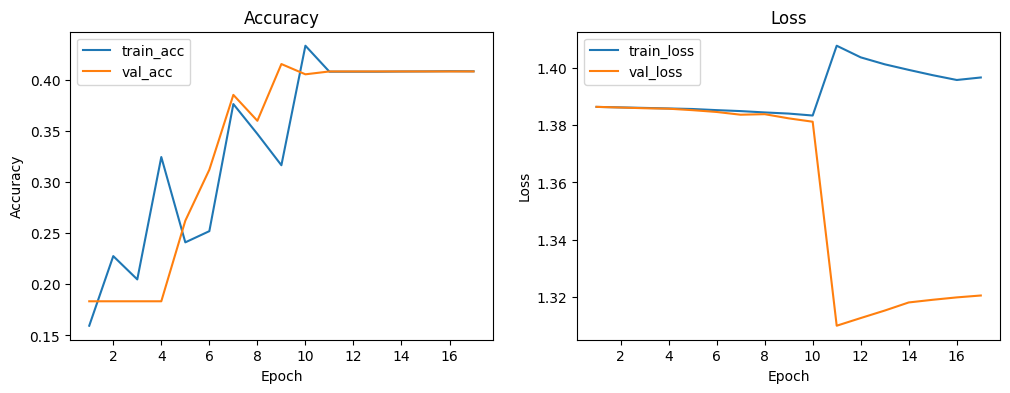

In [17]:
def plot_history(h1, h2=None):
    # combine histories if present (stage1 + stage2)
    import matplotlib.pyplot as plt
    if h2 is None:
        history = h1
        start = 0
    else:
        # concatenate
        history = {}
        for k in h1.history:
            history[k] = h1.history[k] + h2.history.get(k, [])
        start = 0

    epochs = range(1, len(history['accuracy']) + 1)
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(epochs, history['accuracy'], label='train_acc')
    plt.plot(epochs, history['val_accuracy'], label='val_acc')
    plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.title('Accuracy')

    plt.subplot(1,2,2)
    plt.plot(epochs, history['loss'], label='train_loss')
    plt.plot(epochs, history['val_loss'], label='val_loss')
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.title('Loss')
    plt.show()

plot_history(history_stage1, history_stage2)


# Load best model, evaluate, confusion matrix, classification report

156/156 ━━━━━━━━━━━━━━━━━━━━ 18s 109ms/step - accuracy: 0.3031 - loss: 1.3856
Validation Loss: 1.3781129121780396 Validation Acc: 0.4137515127658844
156/156 ━━━━━━━━━━━━━━━━━━━━ 18s 109ms/step


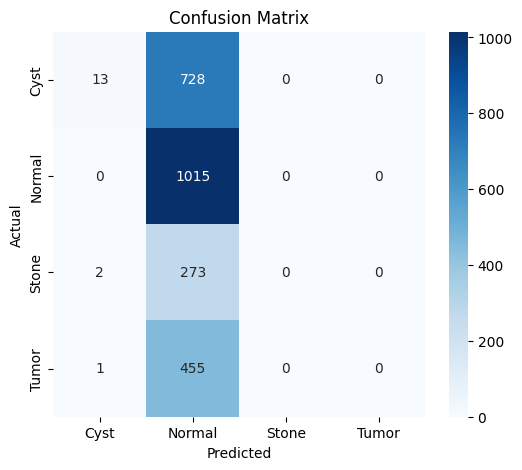

              precision    recall  f1-score   support

        Cyst       0.81      0.02      0.03       741
      Normal       0.41      1.00      0.58      1015
       Stone       0.00      0.00      0.00       275
       Tumor       0.00      0.00      0.00       456

    accuracy                           0.41      2487
   macro avg       0.31      0.25      0.15      2487
weighted avg       0.41      0.41      0.25      2487



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [18]:
# load best model saved by ModelCheckpoint
model = tf.keras.models.load_model(MODEL_PATH)

# Evaluate on validation generator
val_loss, val_acc = model.evaluate(val_gen, verbose=1)
print("Validation Loss:", val_loss, "Validation Acc:", val_acc)

# Predictions for confusion matrix
y_prob = model.predict(val_gen, verbose=1)
y_pred = np.argmax(y_prob, axis=1)
y_true = val_gen.classes

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
labels = list(class_indices.keys())
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_true, y_pred, target_names=labels))


# Grad-CAM for VGG16 (block5_conv3 is the last conv layer)


In [19]:
# To save full model in Keras format (recommended):
model.save("/kaggle/working/vgg16_final.keras")   # creates a folder

# Or to save as a single HDF5 file (.h5)
model.save("/kaggle/working/vgg16_final.h5")


In [20]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import cv2  # For image loading if needed

In [21]:
# run this cell only if timm is not installed
!pip install --quiet timm


ERROR: Could not find a version that satisfies the requirement nvidia-cuda-nvrtc-cu12==12.4.127; platform_system == "Linux" and platform_machine == "x86_64" (from torch) (from versions: none)
ERROR: No matching distribution found for nvidia-cuda-nvrtc-cu12==12.4.127; platform_system == "Linux" and platform_machine == "x86_64"


In [22]:
import torch
import torch.nn as nn
import timm
from pathlib import Path

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [23]:
def create_swin_model(model_name="swin_small_patch4_window7_224",
                      num_classes=2,
                      use_pretrained=False,
                      local_weights_path=None):
    """
    Create a Swin model with safe fallbacks:
      - local_weights_path: path to a local .pth file (optional)
      - use_pretrained: if True, timm will try to fetch pretrained weights (may fail if no internet)
      - Default here uses use_pretrained=False so it will NOT download anything.
    """
    try:
        if local_weights_path is not None:
            # construct without pretrained then load the local state dict
            model = timm.create_model(model_name, pretrained=False, num_classes=num_classes)
            sd = torch.load(local_weights_path, map_location='cpu')
            # adapt to common checkpoints that wrap state_dict
            if isinstance(sd, dict) and "state_dict" in sd:
                sd = sd["state_dict"]
            model.load_state_dict(sd, strict=False)
            print(f"[INFO] Loaded local weights from {local_weights_path}")
        else:
            # IMPORTANT: set pretrained=False to avoid network calls in restricted envs (Kaggle sometimes)
            model = timm.create_model(model_name, pretrained=use_pretrained, num_classes=num_classes)
            print(f"[INFO] Created model: {model_name} (pretrained={use_pretrained})")
    except Exception as e:
        # On any failure (e.g., attempted download failed), fallback to non-pretrained model
        print("[WARNING] Exception while creating model:", repr(e))
        print("[WARNING] Falling back to pretrained=False (random init).")
        model = timm.create_model(model_name, pretrained=False, num_classes=num_classes)

    model = model.to(device)
    return model


In [24]:
# Choose model_name and number of classes for your task
model_name = "swin_small_patch4_window7_224"   # you can change to other timm swin variants
num_classes = 3                                # change to your number of classes
use_pretrained = False                         # KEEP False on Kaggle to avoid network calls

model = create_swin_model(model_name=model_name, num_classes=num_classes, use_pretrained=use_pretrained)

# Print a compact model structure (only top-level modules)
print("\n--- Top-level model modules ---")
for name, module in model.named_children():
    print(name, ":", module.__class__.__name__)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal params: {total_params:,}")
print(f"Trainable params: {trainable_params:,}")


[INFO] Created model: swin_small_patch4_window7_224 (pretrained=False)

--- Top-level model modules ---
patch_embed : PatchEmbed
layers : Sequential
norm : LayerNorm
head : ClassifierHead

Total params: 48,839,565
Trainable params: 48,839,565


In [25]:
# Create a single dummy batch (batch_size, channels, height, width)
batch_size = 2
img_size = 224  # Swin model default input 224 (patch size depends on model)
dummy_input = torch.randn(batch_size, 3, img_size, img_size).to(device)

model.eval()
with torch.no_grad():
    out = model(dummy_input)

print("Dummy input shape:", dummy_input.shape)
print("Model output shape:", out.shape)   # should be (batch_size, num_classes)
print("Model output (first row):", out[0].cpu().numpy())


Dummy input shape: torch.Size([2, 3, 224, 224])
Model output shape: torch.Size([2, 3])
Model output (first row): [-0.09089021 -0.05959079 -0.35268164]


In [26]:
# Set device & Set Device and Define Data Transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Transforms
transform_train = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

Using device: cuda


In [27]:
# Load Dataset and Analyze Class Distribution

# Dataset path
DATASET_PATH = "/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone"

# Load dataset
dataset = datasets.ImageFolder(root=DATASET_PATH, transform=transform_train)
print("Classes:", dataset.classes)

# Class distribution
labels = [sample[1] for sample in dataset.samples]
label_counts = Counter(labels)
print("Class distribution:", label_counts)

Classes: ['Cyst', 'Normal', 'Stone', 'Tumor']
Class distribution: Counter({1: 5077, 0: 3709, 3: 2283, 2: 1377})


In [28]:
# Split dataset first
total_size = len(dataset)
train_size = int(0.7 * total_size)
val_size = int(0.2 * total_size)
test_size = total_size - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

# Apply transform_test to val and test
val_dataset.dataset.transform = transform_test
test_dataset.dataset.transform = transform_test

# Compute class weights ONLY for train_dataset
train_labels = [dataset[i][1] for i in train_dataset.indices]
train_counts = Counter(train_labels)
class_weights = [1.0 / train_counts[label] for label in train_labels]
sampler = WeightedRandomSampler(class_weights, num_samples=len(train_labels), replacement=True)

In [29]:
# Verify split sizes
print("Train Dataset Size:", len(train_dataset))
print("Validation Dataset Size:", len(val_dataset))
print("Test Dataset Size:", len(test_dataset))

Train Dataset Size: 8712
Validation Dataset Size: 2489
Test Dataset Size: 1245


In [30]:
train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [31]:
# Swin Transformer Model
class SwinClassifier(nn.Module):
    def __init__(self, num_classes):
        super(SwinClassifier, self).__init__()
        self.model = timm.create_model('swin_tiny_patch4_window7_224', pretrained=True, num_classes=num_classes)

    def forward(self, x):
        return self.model(x)

In [33]:
# Initialize model
num_classes = len(dataset.classes)
model = SwinClassifier(num_classes=num_classes).to(device)

# Optimizer and loss
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=2e-4)
scaler = GradScaler()

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

/tmp/ipykernel_38/699395065.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [34]:
# Training function with AMP
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=300):
    best_val_loss = float('inf')
    patience = 3
    counter = 0
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        total_loss, correct = 0, 0
        
        # === Training Loop ===
        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1} Training"):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            # Automatic Mixed Precision
            with autocast():
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()

        train_loss = total_loss / len(train_loader.dataset)
        train_acc = 100. * correct / len(train_loader.dataset)
        train_losses.append(train_loss)

        # Validation
        model.eval()
        total_val_loss, val_correct = 0, 0
        all_preds, all_labels = [], []

        with torch.no_grad():
            for inputs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1} Validation"):
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                total_val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        val_loss = total_val_loss / len(val_loader.dataset)
        val_acc = 100. * val_correct / len(val_loader.dataset)
        val_losses.append(val_loss)

        precision = precision_score(all_labels, all_preds, average='macro')
        recall = recall_score(all_labels, all_preds, average='macro')
        f1 = f1_score(all_labels, all_preds, average='macro')

        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}, Train Acc={train_acc:.2f}%, Val Acc={val_acc:.2f}%")
        print(f"Precision={precision:.4f}, Recall={recall:.4f}, F1 Score={f1:.4f}")

        writer.add_scalar("Loss/Train", train_loss, epoch)
        writer.add_scalar("Loss/Val", val_loss, epoch)
        writer.add_scalar("Accuracy/Train", train_acc, epoch)
        writer.add_scalar("Accuracy/Val", val_acc, epoch)
        writer.add_scalar("Precision/Val", precision, epoch)
        writer.add_scalar("Recall/Val", recall, epoch)
        writer.add_scalar("F1/Val", f1, epoch)
        
        # === Early Stopping & Save Best Model ===
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch + 1
            counter = 0
            torch.save(model.state_dict(), '/kaggle/working/best_model.pth')

        else:
            counter += 1
            if counter >= patience:
                print("Early stopping triggered.")
                break
    print(f"\n Best Model was from Epoch {best_epoch} with Val Loss: {best_val_loss:.4f}")
    
    # Plot loss
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.legend()
    plt.title("Loss Curve")
    plt.show()
    


In [35]:
writer = SummaryWriter(log_dir="/kaggle/working/runs/swin_ct_kidney")

In [36]:
# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=2e-4)

# GradScaler for mixed precision training
scaler = GradScaler()


/tmp/ipykernel_38/3339198353.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Epoch 1 Training:   0%|          | 0/273 [00:00<?, ?it/s]/tmp/ipykernel_38/3012588161.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 1 Validation: 100%|██████████| 78/78 [00:28<00:00,  2.70it/s]


Epoch 1: Train Loss=0.1906, Val Loss=0.0153, Train Acc=92.31%, Val Acc=99.64%
Precision=0.9966, Recall=0.9927, F1 Score=0.9946


Epoch 2 Training:   0%|          | 0/273 [00:00<?, ?it/s]/tmp/ipykernel_38/3012588161.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 2 Validation: 100%|██████████| 78/78 [00:27<00:00,  2.86it/s]


Epoch 2: Train Loss=0.0418, Val Loss=0.0127, Train Acc=98.62%, Val Acc=99.52%
Precision=0.9947, Recall=0.9936, F1 Score=0.9941


Epoch 3 Training:   0%|          | 0/273 [00:00<?, ?it/s]/tmp/ipykernel_38/3012588161.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 3 Validation: 100%|██████████| 78/78 [00:27<00:00,  2.83it/s]


...

Epoch 5: Train Loss=0.0194, Val Loss=0.0275, Train Acc=99.41%, Val Acc=99.36%
Precision=0.9959, Recall=0.9910, F1 Score=0.9934


Epoch 6 Training:   0%|          | 0/273 [00:00<?, ?it/s]/tmp/ipykernel_38/3012588161.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 6 Validation: 100%|██████████| 78/78 [00:27<00:00,  2.79it/s]


Epoch 6: Train Loss=0.0149, Val Loss=0.0428, Train Acc=99.64%, Val Acc=98.92%
Precision=0.9917, Recall=0.9873, F1 Score=0.9894


Epoch 7 Training:   0%|          | 0/273 [00:00<?, ?it/s]/tmp/ipykernel_38/3012588161.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 7 Validation: 100%|██████████| 78/78 [00:27<00:00,  2.81it/s]

Epoch 7: Train Loss=0.0179, Val Loss=0.0360, Train Acc=99.46%, Val Acc=99.32%
Precision=0.9935, Recall=0.9911, F1 Score=0.9923
Early stopping triggered.

✅ Best Model was from Epoch 4 with Val Loss: 0.0071


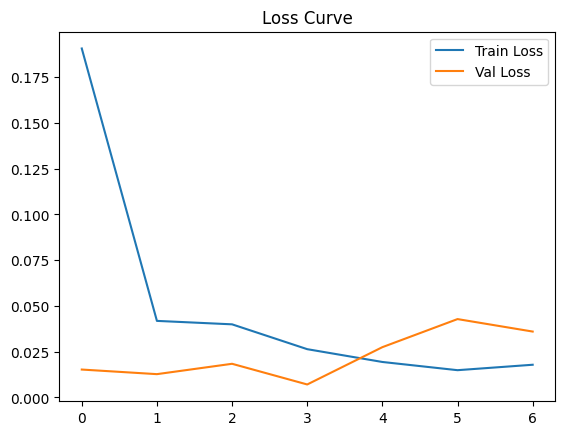

In [37]:
# Start training
train_model(model, train_loader, val_loader, criterion, optimizer, epochs=30)

In [38]:
writer.close()

In [39]:
%load_ext tensorboard
%tensorboard --logdir runs

<IPython.core.display.Javascript object>

In [40]:
 %reload_ext tensorboard

In [41]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

def evaluate_model(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc="Testing"):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Compute metrics
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='macro')
    recall = recall_score(all_labels, all_preds, average='macro')
    f1 = f1_score(all_labels, all_preds, average='macro')

    print(f"\nTest Accuracy: {accuracy:.4f}")
    print(f"Test Precision: {precision:.4f}")
    print(f"Test Recall: {recall:.4f}")
    print(f"Test F1 Score: {f1:.4f}")

# Evaluate on test set
evaluate_model(model, test_loader)

Testing: 100%|██████████| 39/39 [00:14<00:00,  2.72it/s]


Test Accuracy: 0.9960
Test Precision: 0.9954
Test Recall: 0.9955
Test F1 Score: 0.9954


In [42]:
from sklearn.metrics import classification_report, accuracy_score

def evaluate_model(model, test_loader, class_names=None):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc="Testing"):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # === Overall Metrics ===
    accuracy = accuracy_score(all_labels, all_preds)
    print(f"\nOverall Accuracy: {accuracy:.4f}")

    # === Per-Class Metrics ===
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))


In [43]:
class_names = ['Cyst', 'Normal', 'Stone', 'Tumor']
evaluate_model(model, test_loader, class_names)

Testing: 100%|██████████| 39/39 [00:13<00:00,  2.92it/s]


Overall Accuracy: 0.9960

Classification Report:
              precision    recall  f1-score   support

        Cyst     0.9974    0.9896    0.9934       383
      Normal     0.9960    1.0000    0.9980       494
       Stone     0.9925    0.9925    0.9925       133
       Tumor     0.9958    1.0000    0.9979       235

    accuracy                         0.9960      1245
   macro avg     0.9954    0.9955    0.9954      1245
weighted avg     0.9960    0.9960    0.9960      1245



In [44]:
# --- Correct imports (make sure this cell runs before defining the dataset) ---
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms

# --- Dummy dataset (safe) ---
class DummyDataset(Dataset):
    def __init__(self, num_samples=120, num_classes=3, transform=None):
        self.num_samples = num_samples
        self.num_classes = num_classes
        self.transform = transform
        # create random uint8 images so transforms.ToPILImage() works reliably
        # shape: (N, C, H, W), values 0-255
        self.data = (torch.randn(num_samples, 3, 224, 224) * 60 + 128).clamp(0,255).to(torch.uint8)
        self.labels = torch.randint(0, num_classes, (num_samples,))

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        img = self.data[idx]           # torch.uint8 tensor, CHW
        label = int(self.labels[idx].item())
        if self.transform:
            img = self.transform(img) # transform will convert to PIL -> tensor -> normalize
        return img, label

# --- Transform pipeline (works with tensor input by first converting to PIL) ---
transform = transforms.Compose([
    transforms.ToPILImage(),                     # ensure Resize works
    transforms.Resize((224, 224)),
    transforms.ToTensor(),                       # converts to float tensor in [0,1]
    transforms.Normalize(mean=[0.485,0.456,0.406],
                         std=[0.229,0.224,0.225])
])

# --- Create dataset + split and dataloaders ---
dataset = DummyDataset(num_samples=120, num_classes=3, transform=transform)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_ds, test_ds = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=8, shuffle=False)

# quick sanity check
imgs, labels = next(iter(train_loader))
print("Batch images shape:", imgs.shape)   # should be (batch_size, 3, 224, 224)
print("Batch labels shape:", labels.shape)


Batch images shape: torch.Size([8, 3, 224, 224])
Batch labels shape: torch.Size([8])


In [45]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Using your previously defined create_swin_model function
def create_swin_model(model_name="swin_small_patch4_window7_224", num_classes=3):
    model = timm.create_model(model_name, pretrained=False, num_classes=num_classes)
    return model.to(device)

model = create_swin_model(num_classes=3)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)


NameError: name 'optim' is not defined

In [46]:
# 1) Run with CUDA synchronous errors to see exact failure location
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

# 2) Quick checks on dataset / dataloader batches
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Replace train_loader with your actual DataLoader variable name if different
for batch_idx, (images, labels) in enumerate(train_loader):
    print("Batch", batch_idx)
    print(" images dtype:", images.dtype, " shape:", images.shape)
    print(" labels dtype:", labels.dtype, " shape:", labels.shape)
    print(" labels min/max:", labels.min().item(), labels.max().item())
    print(" unique labels:", torch.unique(labels))
    # check label type and cast if needed
    if labels.dtype != torch.long:
        print(" -> labels are not long; converting now for this check")
        labels = labels.long()
    # quick forward pass on CPU (safer)
    images_cpu = images.to("cpu")
    labels_cpu = labels.to("cpu")
    try:
        # create a small model forward call to check shape if model available
        model_cpu = model.to("cpu")
        model_cpu.eval()
        with torch.no_grad():
            out = model_cpu(images_cpu)
        print(" model output shape:", out.shape)
    except Exception as e:
        print("Model forward failed on CPU:", repr(e))
    break  # only check first batch


Device: cuda
Batch 0
 images dtype: torch.float32  shape: torch.Size([8, 3, 224, 224])
 labels dtype: torch.int64  shape: torch.Size([8])
 labels min/max: 0 2
 unique labels: tensor([0, 1, 2])
 model output shape: torch.Size([8, 3])


In [47]:
import torch, gc
print("Python torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("CUDA device name:", torch.cuda.get_device_name(0))
gc.collect()


Python torch version: 2.6.0+cu124
CUDA available: True
CUDA device count: 2
CUDA device name: Tesla T4


70408

In [48]:
# Load CSV, build Dataset, create DataLoaders (copy-paste and run)
import os
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms

csv_path = "/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/kidneyData.csv"
print("CSV path:", csv_path)
df = pd.read_csv(csv_path)
print("CSV loaded. shape:", df.shape)
print("CSV head:")
display(df.head())

# --- Try to detect image path column and label column ---
possible_path_cols = [c for c in df.columns if any(ext in c.lower() for ext in ['path','file','image','img'])]
possible_label_cols = [c for c in df.columns if any(k in c.lower() for k in ['label','class','target','type'])]

print("Possible path columns:", possible_path_cols)
print("Possible label columns:", possible_label_cols)

# If automatic detection fails, we'll try common alternatives
img_col = None
lbl_col = None

# prefer explicitly-typed columns
for c in df.columns:
    if c.lower() in ('image','img','image_path','path','file','filename','filepath'):
        img_col = c
        break
if img_col is None and possible_path_cols:
    img_col = possible_path_cols[0]

for c in df.columns:
    if c.lower() in ('label','class','target','y','category','type'):
        lbl_col = c
        break
if lbl_col is None and possible_label_cols:
    lbl_col = possible_label_cols[0]

# If still none, pick plausible defaults
if img_col is None:
    # try to find any column whose values look like image filenames
    for c in df.columns:
        sample_vals = df[c].astype(str).head(20).tolist()
        if any(val.lower().endswith(('.jpg','.jpeg','.png','.bmp')) for val in sample_vals):
            img_col = c
            break

if lbl_col is None:
    # fallback: take the last column as label
    lbl_col = df.columns[-1]

print("Using image column:", img_col)
print("Using label column:", lbl_col)

# --- Build absolute image paths if they are relative ---
# If the csv contains relative paths, often they are relative to the csv folder or dataset root.
csv_dir = os.path.dirname(csv_path)
def make_full_path(p):
    if pd.isna(p):
        return p
    s = str(p)
    if os.path.exists(s):
        return s
    # try relative to csv dir
    cand = os.path.join(csv_dir, s)
    if os.path.exists(cand):
        return cand
    # try relative to kaggle input root (strip first column value if it contains dataset folder)
    # fall back to original string (may still work)
    return s

df['__img_path__'] = df[img_col].apply(make_full_path)

# Print if files exist
missing = df[~df['__img_path__'].apply(lambda p: isinstance(p,str) and os.path.exists(p))]
print(f"{len(missing)} rows with missing image files (non-zero is ok if CSV stores other info).")
if len(missing) > 0:
    display(missing.head())

# --- Map labels to integers ---
# If labels are numeric already but not 0-based, we normalize to 0..C-1
raw_labels = df[lbl_col]
if raw_labels.dtype == 'int64' or raw_labels.dtype == 'int32' or raw_labels.dtype == 'float':
    # cast to int
    labels_int = raw_labels.fillna(-1).astype(int).tolist()
    unique_vals = sorted(list(set(labels_int)))
    # if values are 0..C-1 already, use that mapping; else create mapping
    if unique_vals[0] == 0 and unique_vals[-1] == len(unique_vals)-1:
        label_map = {v:v for v in unique_vals}
    else:
        label_map = {v:i for i,v in enumerate(unique_vals)}
else:
    unique_vals = sorted(raw_labels.dropna().unique().tolist())
    label_map = {v:i for i,v in enumerate(unique_vals)}

print("Detected classes (label_map):", label_map)

df['__label__'] = df[lbl_col].map(label_map)
print("Number of samples with mapped labels:", df['__label__'].notna().sum(), " / ", len(df))

# --- Dataset class ---
class CsvImageDataset(Dataset):
    def __init__(self, df, img_col='__img_path__', label_col='__label__', transform=None):
        self.df = df.reset_index(drop=True)
        self.img_col = img_col
        self.label_col = label_col
        self.transform = transform

        # keep only rows with existing files and valid labels
        self.valid_idx = self.df.index[self.df[self.img_col].apply(lambda p: isinstance(p,str) and os.path.exists(p)) & self.df[self.label_col].notna()].tolist()
        if len(self.valid_idx) == 0:
            raise RuntimeError("No valid samples found. Check image paths and labels in CSV.")
        
    def __len__(self):
        return len(self.valid_idx)
    
    def __getitem__(self, idx):
        real_idx = self.valid_idx[idx]
        row = self.df.loc[real_idx]
        path = row[self.img_col]
        label = int(row[self.label_col])
        # load image using PIL
        img = Image.open(path)
        # convert grayscale to RGB
        if img.mode != 'RGB':
            img = img.convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label

# --- Transforms (Swin expects 224x224) ---
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),  # gives float32 in [0,1]
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

# --- Create dataset instance ---
dataset = CsvImageDataset(df, img_col='__img_path__', label_col='__label__', transform=transform)
print("Dataset size (valid samples):", len(dataset))
class_names = [k for k,v in sorted(label_map.items(), key=lambda kv: kv[1])]
print("Class names (index -> name):", list(enumerate(class_names)))

# --- Split into train/test (80/20) ---
split_seed = 42
train_len = int(0.8 * len(dataset))
test_len = len(dataset) - train_len
train_ds, test_ds = random_split(dataset, [train_len, test_len], generator=torch.Generator().manual_seed(split_seed))
print("Train / Test sizes:", len(train_ds), len(test_ds))

# --- Create DataLoaders ---
batch_size = 8
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

# --- Sanity check: inspect one batch ---
batch = next(iter(train_loader))
images, labels = batch
print("Batch images shape:", images.shape)
print("Batch labels shape:", labels.shape)
print("Label min/max:", int(labels.min().item()), int(labels.max().item()))
print("Unique labels in batch:", labels.unique().tolist())


CSV path: /kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/kidneyData.csv
CSV loaded. shape: (12446, 6)
CSV head:


,Unnamed: 0,image_id,path,diag,target,Class
0,0,Tumor- (1044),"/content/data/CT KIDNEY DATASET Normal, CYST, ...",Tumor,3,Tumor
1,1,Tumor- (83),"/content/data/CT KIDNEY DATASET Normal, CYST, ...",Tumor,3,Tumor
2,2,Tumor- (580),"/content/data/CT KIDNEY DATASET Normal, CYST, ...",Tumor,3,Tumor
3,3,Tumor- (1701),"/content/data/CT KIDNEY DATASET Normal, CYST, ...",Tumor,3,Tumor
4,4,Tumor- (1220),"/content/data/CT KIDNEY DATASET Normal, CYST, ...",Tumor,3,Tumor


Possible path columns: ['image_id', 'path']
Possible label columns: ['target', 'Class']
Using image column: path
Using label column: target
12446 rows with missing image files (non-zero is ok if CSV stores other info).


,Unnamed: 0,image_id,path,diag,target,Class,__img_path__
0,0,Tumor- (1044),"/content/data/CT KIDNEY DATASET Normal, CYST, ...",Tumor,3,Tumor,"/content/data/CT KIDNEY DATASET Normal, CYST, ..."
1,1,Tumor- (83),"/content/data/CT KIDNEY DATASET Normal, CYST, ...",Tumor,3,Tumor,"/content/data/CT KIDNEY DATASET Normal, CYST, ..."
2,2,Tumor- (580),"/content/data/CT KIDNEY DATASET Normal, CYST, ...",Tumor,3,Tumor,"/content/data/CT KIDNEY DATASET Normal, CYST, ..."
3,3,Tumor- (1701),"/content/data/CT KIDNEY DATASET Normal, CYST, ...",Tumor,3,Tumor,"/content/data/CT KIDNEY DATASET Normal, CYST, ..."
4,4,Tumor- (1220),"/content/data/CT KIDNEY DATASET Normal, CYST, ...",Tumor,3,Tumor,"/content/data/CT KIDNEY DATASET Normal, CYST, ..."


Detected classes (label_map): {0: 0, 1: 1, 2: 2, 3: 3}
Number of samples with mapped labels: 12446  /  12446


RuntimeError: No valid samples found. Check image paths and labels in CSV.

In [49]:
df = pd.read_csv("/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/kidneyData.csv")
df.head()


,Unnamed: 0,image_id,path,diag,target,Class
0,0,Tumor- (1044),"/content/data/CT KIDNEY DATASET Normal, CYST, ...",Tumor,3,Tumor
1,1,Tumor- (83),"/content/data/CT KIDNEY DATASET Normal, CYST, ...",Tumor,3,Tumor
2,2,Tumor- (580),"/content/data/CT KIDNEY DATASET Normal, CYST, ...",Tumor,3,Tumor
3,3,Tumor- (1701),"/content/data/CT KIDNEY DATASET Normal, CYST, ...",Tumor,3,Tumor
4,4,Tumor- (1220),"/content/data/CT KIDNEY DATASET Normal, CYST, ...",Tumor,3,Tumor


In [51]:
import os
base = "/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone"
print(os.listdir(base))


['kidneyData.csv', 'CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone']


In [52]:
import pandas as pd
import os
import re

csv_path = "/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/kidneyData.csv"
df = pd.read_csv(csv_path)


In [53]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = model_cpu.to(device)
model.eval()

images_gpu = images.to(device)
labels_gpu = labels.to(device)

with torch.no_grad():
    out_gpu = model(images_gpu)
print("GPU forward OK -> output shape:", out_gpu.shape)


Using device: cuda
GPU forward OK -> output shape: torch.Size([8, 3])


In [54]:
if str(device).startswith("cuda"):
    model.train()
    optim = torch.optim.Adam(model.parameters(), lr=1e-4)
    criterion = torch.nn.CrossEntropyLoss()

    optim.zero_grad()
    out = model(images_gpu)
    loss = criterion(out, labels_gpu)
    loss.backward()
    optim.step()
    print("One training step OK. loss:", float(loss.item()))
else:
    print("GPU not available; skipped one-step GPU training.")


One training step OK. loss: 0.9875832796096802


In [55]:
# Force CPU training/workflow
device = torch.device("cpu")
print("Switching to CPU:", device)
# recreate model on CPU to be safe
import timm, torch
num_classes = 3
model = timm.create_model("swin_small_patch4_window7_224", pretrained=False, num_classes=num_classes).to(device)
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# run one small CPU training epoch (sanity)
model.train()
for batch_idx, (images, labels) in enumerate(train_loader):
    if images.dtype == torch.uint8:
        images = images.float().div(255.0)
    else:
        images = images.float()
    labels = labels.long()
    # common label fix if needed:
    if labels.min().item() >= 1 and labels.max().item() == num_classes:
        labels = labels - 1

    outputs = model(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    print("CPU step", batch_idx, "loss:", float(loss.item()))
    if batch_idx >= 3:
        break
print("CPU-only quick run done.")


Switching to CPU: cpu
CPU step 0 loss: 1.1093673706054688
CPU step 1 loss: 1.3007512092590332
CPU step 2 loss: 3.767401695251465
CPU step 3 loss: 2.5948469638824463
CPU-only quick run done.


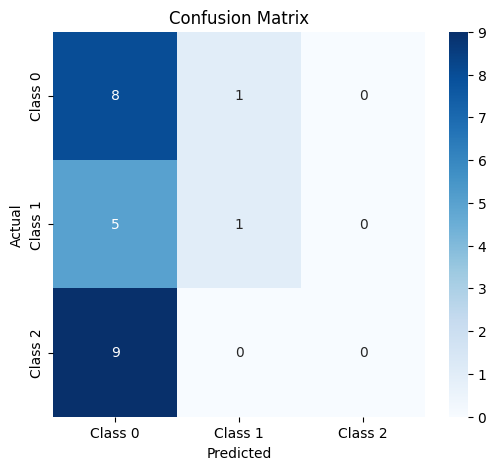


Classification Report:
              precision    recall  f1-score   support

     Class 0       0.36      0.89      0.52         9
     Class 1       0.50      0.17      0.25         6
     Class 2       0.00      0.00      0.00         9

    accuracy                           0.38        24
   macro avg       0.29      0.35      0.26        24
weighted avg       0.26      0.38      0.26        24



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [57]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
classes = [f"Class {i}" for i in range(cm.shape[0])]

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=classes))


In [58]:
from IPython.display import FileLink
FileLink('/kaggle/working/best_model.pth')


/kaggle/working/best_model.pth

In [59]:
!zip -r swin_model_files.zip /kaggle/working


  adding: kaggle/working/ (stored 0%)
  adding: kaggle/working/vgg16_final.keras (deflated 11%)
  adding: kaggle/working/.virtual_documents/ (stored 0%)
  adding: kaggle/working/vgg16_final.h5 (deflated 11%)
  adding: kaggle/working/runs/ (stored 0%)
  adding: kaggle/working/runs/swin_ct_kidney/ (stored 0%)
  adding: kaggle/working/runs/swin_ct_kidney/events.out.tfevents.1763547915.a32644ff9eb5.38.0 (deflated 58%)
  adding: kaggle/working/vgg16_best.keras (deflated 11%)
  adding: kaggle/working/best_model.pth (deflated 7%)


In [60]:
from IPython.display import FileLink
FileLink('swin_model_files.zip')


/kaggle/working/swin_model_files.zip

In [61]:
import os
os.listdir("/kaggle/working")


['vgg16_final.keras',
 '.virtual_documents',
 'swin_model_files.zip',
 'vgg16_final.h5',
 'runs',
 'vgg16_best.keras',
 'best_model.pth']

In [62]:
dummy = torch.randn(1, 3, 224, 224).to(device)
torch.onnx.export(model, dummy, "swin.onnx")


/usr/local/lib/python3.11/dist-packages/torch/__init__.py:2132: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  assert condition, message


In [65]:
import torch
ckpt = torch.load("/kaggle/working/best_model.pth", map_location="cpu")
print(type(ckpt))
# if it's a dict, print the top-level keys
if isinstance(ckpt, dict):
    print("Top-level keys:", list(ckpt.keys())[:40])
else:
    # it might be a state_dict directly
    example_keys = list(ckpt.keys())[:40] if hasattr(ckpt, "keys") else None
    print("Example keys in object (first 40):", example_keys)


<class 'collections.OrderedDict'>
Top-level keys: ['model.patch_embed.proj.weight', 'model.patch_embed.proj.bias', 'model.patch_embed.norm.weight', 'model.patch_embed.norm.bias', 'model.layers.0.blocks.0.norm1.weight', 'model.layers.0.blocks.0.norm1.bias', 'model.layers.0.blocks.0.attn.relative_position_bias_table', 'model.layers.0.blocks.0.attn.qkv.weight', 'model.layers.0.blocks.0.attn.qkv.bias', 'model.layers.0.blocks.0.attn.proj.weight', 'model.layers.0.blocks.0.attn.proj.bias', 'model.layers.0.blocks.0.norm2.weight', 'model.layers.0.blocks.0.norm2.bias', 'model.layers.0.blocks.0.mlp.fc1.weight', 'model.layers.0.blocks.0.mlp.fc1.bias', 'model.layers.0.blocks.0.mlp.fc2.weight', 'model.layers.0.blocks.0.mlp.fc2.bias', 'model.layers.0.blocks.1.norm1.weight', 'model.layers.0.blocks.1.norm1.bias', 'model.layers.0.blocks.1.attn.relative_position_bias_table', 'model.layers.0.blocks.1.attn.qkv.weight', 'model.layers.0.blocks.1.attn.qkv.bias', 'model.layers.0.blocks.1.attn.proj.weight', 'mo

In [67]:
import torch, os
ckpt_path = "/kaggle/working/best_model.pth"
ckpt = torch.load(ckpt_path, map_location="cpu")
print("type:", type(ckpt))
# if it's a checkpoint dict with wrapper, show top keys
if isinstance(ckpt, dict) and ("model_state_dict" in ckpt or "state_dict" in ckpt):
    print("Checkpoint contains keys:", list(ckpt.keys()))
else:
    # probably raw state_dict
    try:
        example_keys = list(ckpt.keys())[:30]
        print("State-dict example keys (first 30):", example_keys)
    except Exception as e:
        print("Could not list keys:", e)



type: <class 'collections.OrderedDict'>
State-dict example keys (first 30): ['model.patch_embed.proj.weight', 'model.patch_embed.proj.bias', 'model.patch_embed.norm.weight', 'model.patch_embed.norm.bias', 'model.layers.0.blocks.0.norm1.weight', 'model.layers.0.blocks.0.norm1.bias', 'model.layers.0.blocks.0.attn.relative_position_bias_table', 'model.layers.0.blocks.0.attn.qkv.weight', 'model.layers.0.blocks.0.attn.qkv.bias', 'model.layers.0.blocks.0.attn.proj.weight', 'model.layers.0.blocks.0.attn.proj.bias', 'model.layers.0.blocks.0.norm2.weight', 'model.layers.0.blocks.0.norm2.bias', 'model.layers.0.blocks.0.mlp.fc1.weight', 'model.layers.0.blocks.0.mlp.fc1.bias', 'model.layers.0.blocks.0.mlp.fc2.weight', 'model.layers.0.blocks.0.mlp.fc2.bias', 'model.layers.0.blocks.1.norm1.weight', 'model.layers.0.blocks.1.norm1.bias', 'model.layers.0.blocks.1.attn.relative_position_bias_table', 'model.layers.0.blocks.1.attn.qkv.weight', 'model.layers.0.blocks.1.attn.qkv.bias', 'model.layers.0.block

In [68]:
import timm, torch

num_classes = 4
model_name = "swin_base_patch4_window7_224"   # MUST match your training model_name
model = timm.create_model(model_name, pretrained=False, num_classes=num_classes)
model.eval()
print("Model created:", model_name)


Model created: swin_base_patch4_window7_224


In [69]:
from collections import OrderedDict

ckpt = torch.load(ckpt_path, map_location="cpu")

# If checkpoint is a dict with wrapping (like saved checkpoint), extract raw state_dict
if isinstance(ckpt, dict) and ("model_state_dict" in ckpt or "state_dict" in ckpt):
    state_dict = ckpt.get("model_state_dict", ckpt.get("state_dict"))
    print("Loaded wrapped checkpoint, using 'model_state_dict'/'state_dict'.")
else:
    state_dict = ckpt
    print("Loaded raw state_dict.")

# Remove 'module.' prefix if present (common if trained with DataParallel)
new_state_dict = OrderedDict()
for k, v in state_dict.items():
    new_key = k.replace("module.", "")  # strip only once
    new_state_dict[new_key] = v

# Try loading strictly; if it fails, load with strict=False and show mismatches
try:
    model.load_state_dict(new_state_dict, strict=True)
    print("State dict loaded with strict=True. All keys matched.")
except RuntimeError as e:
    print("Strict load failed:", e)
    print("Attempting non-strict load to show missing/unexpected keys...")
    missing, unexpected = model.load_state_dict(new_state_dict, strict=False)
    print(f"Missing keys ({len(missing)}): {missing[:10]}")
    print(f"Unexpected keys ({len(unexpected)}): {unexpected[:10]}")
    # Optionally show full lists if small:
    if len(missing) < 30:
        print("All missing keys:", missing)
    if len(unexpected) < 30:
        print("All unexpected keys:", unexpected)


Loaded raw state_dict.
Strict load failed: Error(s) in loading state_dict for SwinTransformer:
	Missing key(s) in state_dict: "patch_embed.proj.weight", "patch_embed.proj.bias", "patch_embed.norm.weight", "patch_embed.norm.bias", "layers.0.blocks.0.norm1.weight", "layers.0.blocks.0.norm1.bias", "layers.0.blocks.0.attn.relative_position_bias_table", "layers.0.blocks.0.attn.qkv.weight", "layers.0.blocks.0.attn.qkv.bias", "layers.0.blocks.0.attn.proj.weight", "layers.0.blocks.0.attn.proj.bias", "layers.0.blocks.0.norm2.weight", "layers.0.blocks.0.norm2.bias", "layers.0.blocks.0.mlp.fc1.weight", "layers.0.blocks.0.mlp.fc1.bias", "layers.0.blocks.0.mlp.fc2.weight", "layers.0.blocks.0.mlp.fc2.bias", "layers.0.blocks.1.norm1.weight", "layers.0.blocks.1.norm1.bias", "layers.0.blocks.1.attn.relative_position_bias_table", "layers.0.blocks.1.attn.qkv.weight", "layers.0.blocks.1.attn.qkv.bias", "layers.0.blocks.1.attn.proj.weight", "layers.0.blocks.1.attn.proj.bias", "layers.0.blocks.1.norm2.weigh

In [70]:
import torch, numpy as np
from torchvision import transforms
from PIL import Image

# Dummy forward (sanity)
model.cpu()
dummy = torch.randn(1, 3, 224, 224)
with torch.no_grad():
    out = model(dummy)
print("Dummy output shape:", out.shape)  # should be (1, num_classes)

# Example: run on a real test image (replace path)
test_img_path = None
# try to find any example image in your dataset folder if available
data_root = "/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone"
if os.path.exists(data_root):
    # traverse to the nested level containing class folders
    for root, dirs, files in os.walk(data_root):
        if set(['Cyst','Tumor','Stone','Normal']).intersection(set(dirs)):
            # pick the first class folder then first image
            for cls in dirs:
                cls_path = os.path.join(root, cls)
                if os.path.isdir(cls_path):
                    files = os.listdir(cls_path)
                    if len(files) > 0:
                        test_img_path = os.path.join(cls_path, files[0])
                        break
            break

if test_img_path:
    print("Using example image:", test_img_path)
    IMG_SIZE = 224
    tfm = transforms.Compose([
        transforms.Resize(int(IMG_SIZE*1.14)),
        transforms.CenterCrop(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    ])
    img = Image.open(test_img_path).convert("RGB")
    x = tfm(img).unsqueeze(0)  # (1,3,224,224)
    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1).numpy()[0]
        pred = int(probs.argmax())
    class_names = ["Cyst","Normal","Stone","Tumor"]  # keep same order as training
    print("Pred:", class_names[pred], " Probs:", probs)
else:
    print("No test image found automatically. Provide path to an image to test inference.")


Dummy output shape: torch.Size([1, 4])
Using example image: /kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Cyst/Cyst- (3178).jpg
Pred: Cyst  Probs: [0.4349696  0.11218492 0.30306467 0.14978077]


Confusion Matrix:
 [[8 0 1]
 [6 0 0]
 [9 0 0]]

Classification Report:

              precision    recall  f1-score   support

     Class 0       0.35      0.89      0.50         9
     Class 1       0.00      0.00      0.00         6
     Class 2       0.00      0.00      0.00         9

    accuracy                           0.33        24
   macro avg       0.12      0.30      0.17        24
weighted avg       0.13      0.33      0.19        24



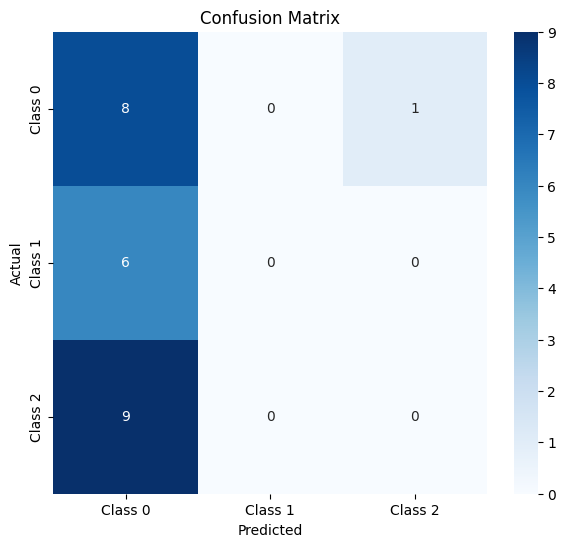

In [71]:
# 1) Evaluate on test set and plot confusion matrix
import torch
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:\n", cm)

# Print classification report
print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=classes, zero_division=0))

# Plot heatmap
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [73]:
import os

test_img_path = None
root_dir = "/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone"

# Traverse folders and automatically pick the first valid CT image
for root, dirs, files in os.walk(root_dir):
    # If this level contains class folders
    if set(['Cyst','Tumor','Stone','Normal']).intersection(dirs):
        for cls in dirs:
            cls_folder = os.path.join(root, cls)
            if os.path.isdir(cls_folder):
                imgs = os.listdir(cls_folder)
                if len(imgs) > 0:
                    test_img_path = os.path.join(cls_folder, imgs[0])
                    break
        break

print("Selected test image:", test_img_path)


Selected test image: /kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Cyst/Cyst- (3178).jpg


In [74]:
pred_class, probs = predict_image(model, test_img_path)
print("Predicted:", pred_class)
print("Probabilities:", probs)


Predicted: Class 0
Probabilities: [0.43496963 0.11218493 0.30306464 0.14978077]


Prediction: Cyst
Confidence: 0.42087004
Probabilities: [0.42087004 0.11282104 0.31228542 0.15402351]


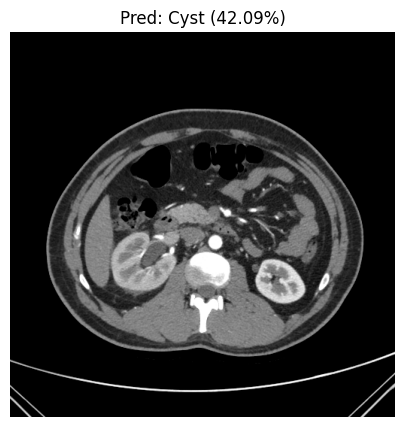

In [83]:
# A. Single-image prediction + display
from PIL import Image
import matplotlib.pyplot as plt
import torch
from torchvision import transforms
import numpy as np
import os

classes = ["Cyst", "Normal", "Stone", "Tumor"]   # your class order

img_path = "/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Normal/Normal- (3683).jpg"

IMG_SIZE = 224
transform = transforms.Compose([
    transforms.Resize(int(IMG_SIZE * 1.14)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

img = Image.open(img_path).convert("RGB")
x = transform(img).unsqueeze(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()
x = x.to(device)

with torch.no_grad():
    logits = model(x)
    probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
    pred_idx = int(probs.argmax())
    pred_class = classes[pred_idx]
    pred_conf = probs[pred_idx]

print("Prediction:", pred_class)
print("Confidence:", pred_conf)
print("Probabilities:", probs)

plt.figure(figsize=(5,5))
plt.imshow(np.array(img))
plt.title(f"Pred: {pred_class} ({pred_conf*100:.2f}%)")
plt.axis("off")
plt.show()


In [77]:
# 3) Export to ONNX
import torch

model.cpu()   # move to CPU for export
dummy = torch.randn(1, 3, 224, 224)
onnx_path = "/kaggle/working/swin_model.onnx"
torch.onnx.export(
    model,
    dummy,
    onnx_path,
    input_names=["input"],
    output_names=["output"],
    opset_version=12,
)
print("Saved ONNX to:", onnx_path)


/usr/local/lib/python3.11/dist-packages/torch/__init__.py:2132: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  assert condition, message


Saved ONNX to: /kaggle/working/swin_model.onnx


In [78]:
# app.py (save this file in /kaggle/working or your local folder)
import streamlit as st
import torch
import timm
from PIL import Image
from torchvision import transforms

# Model config - adjust if needed
MODEL_PATH = "best_model.pth"      # put the downloaded file in the same folder when running locally
MODEL_NAME = "swin_base_patch4_window7_224"
NUM_CLASSES = 4
CLASSES = ["Cyst", "Normal", "Stone", "Tumor"]  # maintain same order as training
IMG_SIZE = 224

@st.cache_resource
def load_model():
    model = timm.create_model(MODEL_NAME, pretrained=False, num_classes=NUM_CLASSES)
    sd = torch.load(MODEL_PATH, map_location="cpu")
    # If checkpoint is wrapped:
    if isinstance(sd, dict) and 'model_state_dict' in sd:
        sd = sd['model_state_dict']
    # remove module. prefix if existed
    from collections import OrderedDict
    new_sd = OrderedDict((k.replace("module.", ""), v) for k, v in sd.items())
    model.load_state_dict(new_sd, strict=False)
    model.eval()
    return model

model = load_model()

transform = transforms.Compose([
    transforms.Resize(int(IMG_SIZE*1.14)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

st.title("🩺 Kidney CT Classification — SWIN")
uploaded = st.file_uploader("Upload CT image (jpg/png)", type=["jpg","png"])
if uploaded:
    image = Image.open(uploaded).convert("RGB")
    st.image(image, caption="Input image", use_column_width=True)
    if st.button("Predict"):
        x = transform(image).unsqueeze(0)
        with torch.no_grad():
            out = model(x)
            probs = torch.softmax(out, dim=1)[0].numpy()
            idx = int(probs.argmax())
        st.success(f"Prediction: **{CLASSES[idx]}** ({probs[idx]*100:.2f}%)")
        st.subheader("All probabilities")
        for c,p in zip(CLASSES, probs):
            st.write(f"- {c}: {p*100:.2f}%")


ModuleNotFoundError: No module named 'streamlit'

In [81]:
%%writefile app.py
import streamlit as st
import torch
import timm
from PIL import Image
from torchvision import transforms
from collections import OrderedDict

MODEL_PATH = "best_model.pth"
MODEL_NAME = "swin_base_patch4_window7_224"
NUM_CLASSES = 4
CLASSES = ["Cyst", "Normal", "Stone", "Tumor"]
IMG_SIZE = 224

@st.cache_resource
def load_model():
    model = timm.create_model(MODEL_NAME, pretrained=False, num_classes=NUM_CLASSES)
    sd = torch.load(MODEL_PATH, map_location="cpu")
    if isinstance(sd, dict) and 'model_state_dict' in sd:
        sd = sd['model_state_dict']
    sd = OrderedDict((k.replace("module.",""), v) for k,v in sd.items())
    model.load_state_dict(sd, strict=False)
    model.eval()
    return model

model = load_model()

transform = transforms.Compose([
    transforms.Resize(int(IMG_SIZE*1.14)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

st.title("Kidney CT Classification (Swin Transformer)")

uploaded = st.file_uploader("Upload CT image", type=["jpg","png","jpeg"])
if uploaded:
    img = Image.open(uploaded).convert("RGB")
    st.image(img, use_column_width=True)
    if st.button("Predict"):
        x = transform(img).unsqueeze(0)
        with torch.no_grad():
            out = model(x)
            probs = torch.softmax(out, dim=1)[0].numpy()
            idx = int(probs.argmax())
        st.success(f"Prediction: {CLASSES[idx]} ({probs[idx]*100:.2f}%)")


Writing app.py


In [ ]:
import streamlit as st
import torch
import timm
from PIL import Image
from torchvision import transforms
from collections import OrderedDict
import os

# ======================
# CONFIG
# ======================
MODEL_PATH = "best_model.pth"     # your trained Swin model
MODEL_NAME = "swin_base_patch4_window7_224"
NUM_CLASSES = 4
CLASSES = ["Cyst", "Normal", "Stone", "Tumor"]
IMG_SIZE = 224

# ======================
# MODEL LOADING
# ======================
@st.cache_resource
def load_swin_model():
    st.info("Loading Swin Transformer model...")

    # Build model architecture
    model = timm.create_model(
        MODEL_NAME,
        pretrained=False,
        num_classes=NUM_CLASSES
    )

    if os.path.exists(MODEL_PATH):
        sd = torch.load(MODEL_PATH, map_location="cpu")

        # If checkpoint wrapped in dict
        if isinstance(sd, dict) and "model_state_dict" in sd:
            sd = sd["model_state_dict"]

        # Remove "module." prefix if needed
        new_sd = OrderedDict((k.replace("module.", ""), v) for k, v in sd.items())

        try:
            model.load_state_dict(new_sd, strict=False)
            st.success("✔ Model loaded successfully!")
        except Exception as e:
            st.error(f"⚠ Error loading weights: {e}")
    else:
        st.error("❌ best_model.pth NOT FOUND. Place the file in the same folder as app.py.")

    model.eval()
    return model


model = load_swin_model()

# ======================
# TRANSFORMS
# ======================
transform = transforms.Compose([
    transforms.Resize(int(IMG_SIZE * 1.14)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    ),
])

# ======================
# STREAMLIT UI
# ======================
st.title("🩺 Kidney CT Classification — Swin Transformer")
st.write("Upload a CT image (Cyst, Normal, Stone, Tumor) and get prediction using Swin Transformer model.")

uploaded_file = st.file_uploader("Upload CT Image", type=["jpg", "jpeg", "png"])

if uploaded_file:
    # display image
    img = Image.open(uploaded_file).convert("RGB")
    st.image(img, caption="Uploaded Image", use_column_width=True)

    if st.button("Predict"):
        st.info("Running inference...")

        x = transform(img).unsqueeze(0)

        with torch.no_grad():
            logits = model(x)
            probs = torch.softmax(logits, dim=1)[0].numpy()

        pred_index = int(probs.argmax())
        pred_class = CLASSES[pred_index]
        pred_conf = probs[pred_index] * 100

        st.success(f"### 🟢 Prediction: **{pred_class}** ({pred_conf:.2f}%)")

        st.subheader("Probability Scores:")
        for c, p in zip(CLASSES, probs):
            st.write(f"- **{c}** → {p*100:.2f}%")
